# Spatial Proteomics analysis (MACSima)
In this series of notebooks, we will analyze a Miltenyi [MACSima](https://www.miltenyibiotec.com/DE-en/products/macs-imaging-and-spatial-biology/macsima-platform.html?query=:relevance:allCategoriesOR:10000717) dataset using the [Harpy](https://harpy.readthedocs.io/en/latest/) package. We will explore QC, segmentation, feature extraction, interactive object classification, and segmentation-free approaches such as tesselation and pixel-clustering.

When you make use of Harpy for analysis of spatial proteomics data, please cite [Rombaut et al. (2026)](https://academic.oup.com/bioinformatics/article/42/3/btag122/8519620?login=false).

Below, we will work on a 3000 x 3000 pixel subset of the MACSima dataset.

## Import packages

In [1]:
import os
import harpy as hp
import spatialdata_plot
import dask.array as da
import matplotlib.pyplot as plt
import numpy as np
import geopandas as gpd
import scanpy as sc

_ = spatialdata_plot

## 1. Read SpatialData
Harpy provides a convenient MACSima reader, [`hp.io.macsima`](https://harpy.readthedocs.io/en/latest/generated/harpy.io.macsima.html#harpy.io.macsima), which reads the data preprocessed by [MACS iQ View](https://www.miltenyibiotec.com/UN-en/products/macs-iq-view-3d-large-volume-software.html) and can be used to construct a `SpatialData` object directly from the preprocessed dataset.

However, for the purposes of this training, we already completed this step and cropped the dataset to a 3000 x 3000 region of interest. We can fetch it from our registry using the code below.

In [2]:
import tempfile
from pathlib import Path

from spatialdata import read_zarr

tmp = tempfile.TemporaryDirectory(prefix="macsima_")
output_dir = Path(tmp.name)

path = None

sdata = hp.datasets.macsima_colorectal_carcinoma_course(
    checkpoint="checkpoint_1",
    path=path,
)

sdata.write(output_dir / "sdata.zarr", overwrite=True)

sdata = read_zarr(sdata.path)

WARNING  Module 'bioio' is not installed. Install it with `pip install bioio` to use `harpy.io.macsima`.           
WARNING  Module 'bioio-ome-tiff' is not installed. Install it with `pip install bioio-ome-tiff` to use             
         `harpy.io.macsima`.                                                                                       


In [3]:
# Let's inspect the SpatialData object
sdata

SpatialData object, with associated Zarr store: C:\Users\julien.mortier\AppData\Local\Temp\macsima_z9f3tny0\sdata.zarr
└── Images
      └── 'REAscreen_IO_CRC': DataTree[cyx] (62, 3000, 3000), (62, 1500, 1500), (62, 750, 750), (62, 375, 375), (62, 187, 187)
with coordinate systems:
    ▸ 'global_1', with elements:
        REAscreen_IO_CRC (Images)
    ▸ 'global_1_micron', with elements:
        REAscreen_IO_CRC (Images)

In [4]:
# To download the raw image data (e.g. to try the MACSima reader or read the images in Qupath for QC or annotation (see 2.2)), we can fetch them from the registry.
# Note that this is a large download (~15 GB) and may take some time.

# from harpy.datasets.registry import get_registry
# registry = get_registry(path=path)
# path_CRC_images = registry.fetch("proteomics/macsima/REAscreen_IO_CRC/REAscreen_IO_CRC_fixed.zip")

### 1.1 Customize channel names
In case of proteomics (or other types of multi-channel imaging data), we often need to be able to customize the channel names. For example, below, we can see that the MACSima reader function automatically assigned clunky names and we may want to simplify these to the relevant biological information.

In [5]:
# Check channel names
original_channel_names = hp.im.get_dataarray(sdata, element_name="REAscreen_IO_CRC").c.data
original_channel_names[:5]

array(['0_DAPI_1_DAPI', '1_CD279_1_CD279__REA1165',
       '1_Bcl 2_1_Bcl 2__REA872', '1_CD209_1_CD209__REAL690',
       '2_FoxP3_1_FoxP3__REA1253'], dtype='<U51')

In [6]:
# First, we define a custom function to clean up the channel names. In this case, we want to extract the part of the channel name that is between the first and second underscores.
import re


def simplify_channel_name(channel: str) -> str:
    match = re.match(r"^\d+_(.*?)_\d+_", channel)
    if match is None:
        return channel
    return match.group(1)


# Apply the function to all channel names to create a new list of channel names
new_channel_names = [simplify_channel_name(channel_name) for channel_name in original_channel_names]

# Using .set_channel_names(), we can update the channel names in the SpatialData object
sdata.set_channel_names(element_name="REAscreen_IO_CRC", channel_names=new_channel_names, write=True)

In [7]:
# Let's check the updated channel names
hp.im.get_dataarray(sdata, element_name="REAscreen_IO_CRC").c.data

array(['DAPI', 'CD279', 'Bcl 2', 'CD209', 'FoxP3', 'CD8a', 'CD44', 'p53',
       'CD138', 'CD45', 'CD15', 'Collagen I', 'CD274', 'Cytokeratin 7',
       'CD223', 'PCNA', 'CD163', 'CD11b', 'CD56', 'CD45RB', 'CD14',
       'CD107a', 'CD4', 'Cytokeratin 14', 'Ki 67', 'CD107b', 'CD31',
       'CD45RA', 'CD38', 'CD66', 'Cleaved PARP1', 'Mast Cell Tryptase',
       'CD66b', 'Podoplanin', 'CD20 Cytoplasmic', 'CD134', 'CD16', 'CD1c',
       'CD68', 'Actin', 'CD79a', 'Cytokeratin 20', 'CD45RO', 'CD11c',
       'Vimentin', 'CD3', 'CD324', 'HLA ABC', 'CD57', 'Cytokeratin 5',
       'CD204', 'Cytokeratin 8', 'MART 1', 'Cytokeratin 19',
       'Melanocyte PMEL', 'Cytokeratin', 'HLA DR', 'beta Catenin',
       'beta Actin', 'CD326', 'Cytokeratin HMW', 'Calponin'], dtype='<U18')

## 2 QC
Next, we need to QC all channels and determine which ones succeeded and which channels should be excluded from the analysis. We also need to determine whether there are technical artifacts in the images (e.g. regions that are out-of-focus regions, contains stitching or registration errors, tissue folds, etc.) that we want to avoid during the analysis. 

Generally, the best approach seems to do this manually by using interactive visualization software such as MACS IQ View, Qupath or Napari-harpy. To do this well, you would need biological and technical insights in the expected staining patterns of each marker.

### 2.1 Napari-harpy

In [8]:
# We can inspect the quality of all channels in Napari
from napari_harpy import Interactive

Interactive(sdata, widgets="viewer")

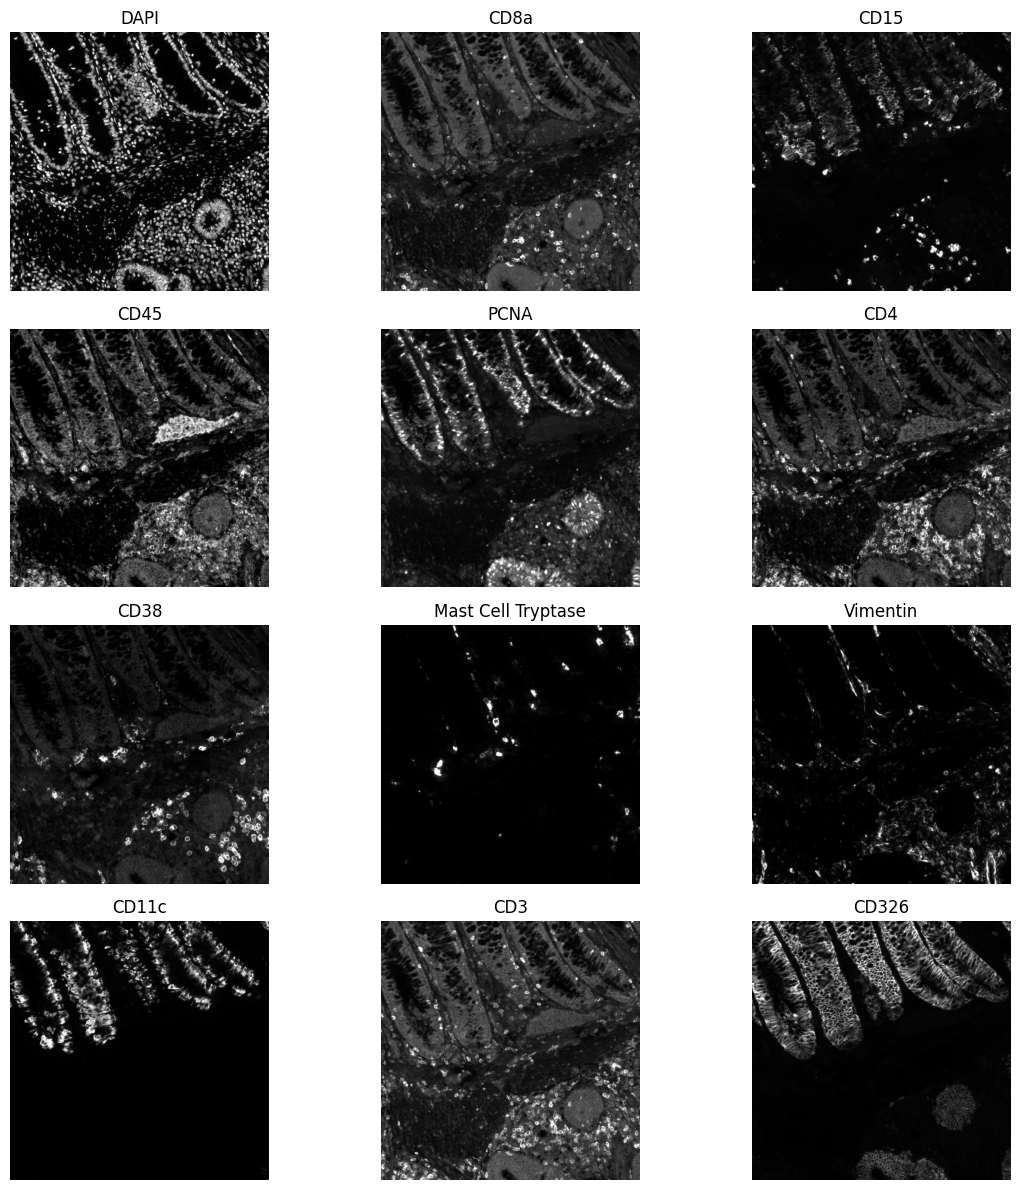

In [9]:
# We can also create static visualizations of the channels using Harpy's plotting functions.
# Here, we will visualize the first 12 channels in a 4x3 grid.
from matplotlib.colors import Normalize

fig, axes = plt.subplots(4, 3, figsize=(12, 12))
_image_name = "REAscreen_IO_CRC"
to_coordinate_system = "global_1"

_channels_to_visualize = [
    "DAPI",
    "CD8a",
    "CD15",
    "CD45",
    "PCNA",
    "CD4",
    "CD38",
    "Mast Cell Tryptase",
    "Vimentin",
    "CD11c",
    "CD3",
    "CD326",
]

se = hp.im.get_dataarray(sdata, element_name=_image_name)
channels = se.c.data

for _ax, _channel in zip(axes.flatten(), _channels_to_visualize, strict=False):
    # Define normalization parameters for visualization (this does not change the underlying image)
    _channel_idx = np.where(channels == _channel)[0].item()
    vmax = da.percentile(se.data[_channel_idx].flatten(), q=99).compute()
    norm = Normalize(vmax=vmax, clip=False)

    render_images_kwargs = {
        "cmap": "gray",
        "norm": norm,
        "scale": "scale1",
    }  # pass scale for faster plotting, but at lower resolution
    show_kwargs = {"title": _channel, "colorbar": False}

    _ax = hp.pl.plot_sdata(
        sdata,
        image_name=_image_name,
        channel=_channel,
        to_coordinate_system=to_coordinate_system,
        render_images_kwargs=render_images_kwargs,
        show_kwargs=show_kwargs,
        ax=_ax,
    )

    _ax.axis("off")  # frameless figure

plt.tight_layout()
plt.show()

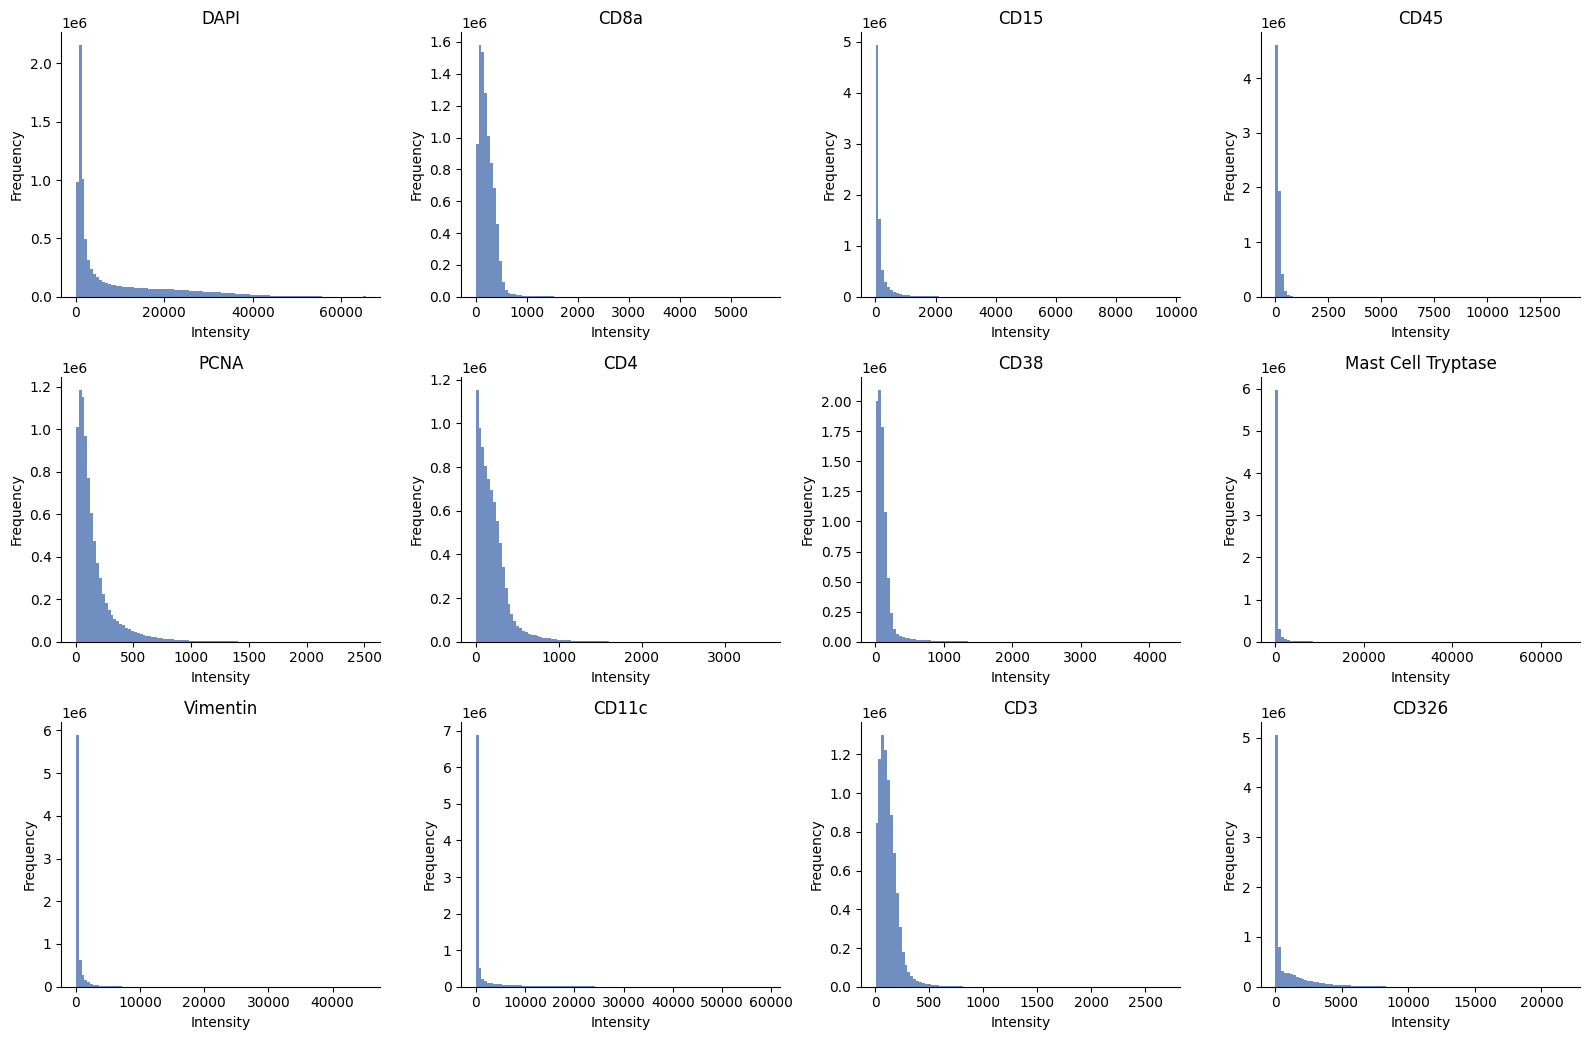

In [10]:
# We can also visualize the distribution of pixel intensities for each channel as a histogram.
ax = hp.qc.image_histogram(
    sdata,
    image_name="REAscreen_IO_CRC",
    channel=_channels_to_visualize,
    ncols=4,
    bins=100,
)

### 2.2 Qupath
Qupath is open source software for bioimage analysis. It has some really nice tools for annotating regions of interest and artifacts in images. We will use these for our dataset and add the results to the SpatialData object.

1. Download the raw image data from the registry using the code above.
2. If necessary, install Qupath using this [link](https://qupath.github.io/).
2. Open Qupath and click `Create project` in the top left corner.
3. Create a new empty folder for the project and click `Select Folder`.
4. You would normally add images to a project by going to `Add images` and providing the image paths. However, this would result in the images being added separately, and we would prefer a merged image containing all channels. To do this, we will use the `read_multichannel_qupath.groovy` script. To run it, go to `Automate`, `Script Editor`, `File`, `Open`, and select the script. In the Qupath script editor, change the folderPath argument to the folder containing the MACSima images and click `Run`. This should add all images to the project as a single image.
5. Explore the image by going to `Brightness & contrast`, select the channels you want to visualize and adjust the settings to improve the visualization.

#### 2.2.1 QC image channels
Using Qupath, we have created a python list of succesful channels and a list for failed channels. Since we're not experts in this tissue, we've aim for removing the channels with obvious flaws (note that this is subjective and very dependent on how well you know the underlying biology and expected staining patterns for the biomarkers).

In [11]:
successful_channels = [
    "DAPI",
    "Bcl 2",  # Clearly contains acquisition bleaching artifacts, but we can annotate these regions to remove them
    "CD8a",
    "FoxP3",
    "CD138",
    "CD15",
    "CD45",
    "Collagen I",
    "CD274",
    "PCNA",
    "CD163",
    "CD56",
    "CD11b",
    "CD45RB",
    "CD14",
    "CD107a",
    "Ki 67",
    "CD4",
    "CD107b",
    "CD31",
    "CD38",
    "CD66b",
    "Cleaved PARP1",
    "Mast Cell Tryptase",
    "CD20 Cytoplasmic",
    "Podoplanin",
    "CD16",
    "CD1c",
    "Actin",
    "CD68",
    "Cytokeratin 20",
    "CD79a",
    "CD45RO",
    "Vimentin",
    "CD11c",
    "CD3",
    "CD324",
    "HLA ABC",
    "CD57",
    "CD204",
    "MART 1",
    "Melanocyte PMEL",
    "Cytokeratin 19",
    "Cytokeratin",
    "HLA DR",
    "beta Catenin",
    "beta Actin",
    "CD326",
    "Calponin",
]

failed_channels = [
    "CD209",  # Uneven illumination
    "CD279",  # Uneven illumination
    "CD44",  # Uneven illumination
    "p53",  # Uneven illumination
    "Cytokeratin 7",  # Uneven illumination
    "CD223",  # Very bright (saturating) artifact
    "Cytokeratin 14",  # Uneven illumination
    "CD45RA",  # Uneven illumination
    "CD66",  # Very bright (saturating) artifact
    "CD134",  # Uneven illumination
    "Cytokeratin 5",  # Uneven illumination
    "Cytokeratin 8",  # Uneven illumination
    "Cytokeratin HMW",  # Uneven illumination
]

#### 2.2.2 Annotate artifacts

1. Open the `Bcl 2 (C3)` channel and annotate the acquisition bleaching regions. Since these are straight lines, you can use the rectangle annotation to annotate all the segments and subsequently merge the annotation by going to `Objects`, `Annotations...`, `Merge selected`. Rename the merged annotation to `acquisition_bleaching` by right-clicking on the annotation in the `Annotations` tab and going to `Set properties`.

2. Open the `DAPI (C1)` channel. In other datasets, we may find some out-of-focus regions, tissue-folds, etc that we could annotate. In this dataset, there is a small very bright region at the top right of the tissue. Annotate it using either the polygon annotation tool or the magic brush, merge any annotation objects you create and rename the merged object `bright_artifact`.

3. Export the annotations. Select all artifact annotations and go to `File`, `Export objects as GeoJSON` and set to `Selected objects` and `Compression` to None. Click `OK` and set the file name to `artifacts.geojson`.

#### 2.2.3 Annotate ROIs
Now, pick a region that looks of interest to you, annotate it and label it `ROI`. Select it and export the GeoJSON as `ROI.geojson.`

#### 2.2.4 Add annotations to sdata

In [17]:
from spatialdata.transformations import Translation, Scale, Sequence

paths_to_GeoJSONs = {
    "artifacts": "D:/training_data/REAscreen_IO_CRC_fixed/artifacts.geojson",  # FIXME: registry.fetch()
    "ROI": "D:/training_data/REAscreen_IO_CRC_fixed/ROI.geojson",  # FIXME: registry.fetch()
}

transformations = {
    "global_1": Translation([-7000, -2000], axes=("x", "y")),
    "global_1_micron": Sequence([Translation([-7000, -2000], axes=("x", "y")), Scale([0.17, 0.17], axes=("x", "y"))]),
}  # For this training, we need to translate the annotations since we are working on a crop of the data of which the origin was reset to (0,0).

for name, path in paths_to_GeoJSONs.items():
    gdf_regions = gpd.read_file(path)
    sdata = hp.sh.add_shapes(
        sdata, input=gdf_regions, output_shapes_name=name, overwrite=True, transformations=transformations
    )

sdata

SpatialData object, with associated Zarr store: C:\Users\julien.mortier\AppData\Local\Temp\macsima_z9f3tny0\sdata.zarr
├── Images
│     └── 'REAscreen_IO_CRC': DataTree[cyx] (62, 3000, 3000), (62, 1500, 1500), (62, 750, 750), (62, 375, 375), (62, 187, 187)
└── Shapes
      ├── 'ROI': GeoDataFrame shape: (1, 5) (2D shapes)
      └── 'artifacts': GeoDataFrame shape: (2, 5) (2D shapes)
with coordinate systems:
    ▸ 'global_1', with elements:
        REAscreen_IO_CRC (Images), ROI (Shapes), artifacts (Shapes)
    ▸ 'global_1_micron', with elements:
        REAscreen_IO_CRC (Images), ROI (Shapes), artifacts (Shapes)

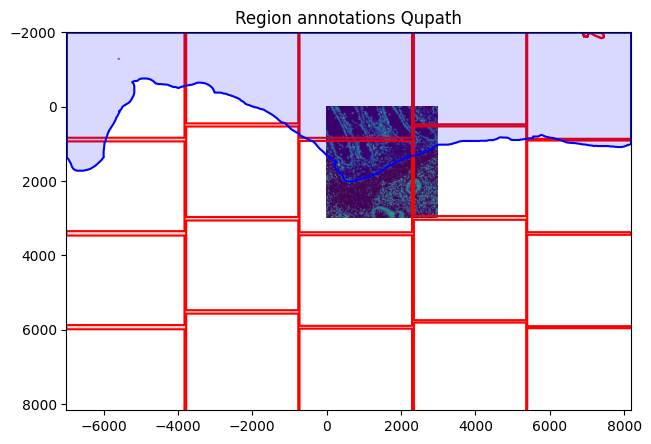

In [20]:
# Let's check whether the region annotations were added correctly
sdata.pl.render_images(element="REAscreen_IO_CRC", channel="DAPI").pl.render_shapes(
    element="artifacts", color="red", fill_alpha=0.15, outline_alpha=1, outline_color="red"
).pl.render_shapes(
    element="ROI",
    color="blue",
    fill_alpha=0.15,
    outline_alpha=1,
    outline_color="blue",
).pl.show(
    coordinate_systems="global_1",
    title="Region annotations Qupath",
    colorbar=False,
)

## 3. Segmentation 

### 3.1 Create subset of segmentation channels

In [9]:
segmentation_channels = [
    "DAPI",
    "CD8a",
    "CD15",
    "CD45",
    "PCNA",
    "CD4",
    "CD38",
    "Mast Cell Tryptase",
    "Vimentin",
    "CD11c",
    "CD3",
    "HLA ABC",
    "CD326",
]

se = hp.im.get_dataarray(sdata, element_name="REAscreen_IO_CRC")
arr = se.sel(c=segmentation_channels).data
arr

dask.array<getitem, shape=(13, 3000, 3000), dtype=uint16, chunksize=(1, 1024, 1024), chunktype=numpy.ndarray>

In [10]:
from spatialdata.transformations import get_transformation

sdata = hp.im.add_image(
    sdata,
    arr=arr,
    output_image_name="REAscreen_IO_CRC_segmentation_channels",
    c_coords=segmentation_channels,
    transformations=get_transformation(sdata["REAscreen_IO_CRC"], get_all=True),
    scale_factors=[2, 2, 2, 2],
    overwrite=True,
)

2026-05-28 12:48:33.695 | INFO     | harpy.image._manager:add_element:47 - Writing results to element 'REAscreen_IO_CRC_segmentation_channels'


In [11]:
sdata["REAscreen_IO_CRC_segmentation_channels"]

<xarray.DataTree>
Group: /
├── Group: /scale0
│       Dimensions:  (c: 13, y: 3000, x: 3000)
│       Coordinates:
│         * c        (c) <U18 936B 'DAPI' 'CD8a' 'CD15' ... 'CD3' 'HLA ABC' 'CD326'
│         * y        (y) float64 24kB 0.5 1.5 2.5 3.5 ... 2.998e+03 2.998e+03 3e+03
│         * x        (x) float64 24kB 0.5 1.5 2.5 3.5 ... 2.998e+03 2.998e+03 3e+03
│       Data variables:
│           image    (c, y, x) uint16 234MB dask.array<chunksize=(1, 1024, 1024), meta=np.ndarray>
├── Group: /scale1
│       Dimensions:  (c: 13, y: 1500, x: 1500)
│       Coordinates:
│         * c        (c) <U18 936B 'DAPI' 'CD8a' 'CD15' ... 'CD3' 'HLA ABC' 'CD326'
│         * y        (y) float64 12kB 1.0 3.0 5.0 7.0 ... 2.995e+03 2.997e+03 2.999e+03
│         * x        (x) float64 12kB 1.0 3.0 5.0 7.0 ... 2.995e+03 2.997e+03 2.999e+03
│       Data variables:
│           image    (c, y, x) uint16 58MB dask.array<chunksize=(1, 1024, 1024), meta=np.ndarray>
├── Group: /scale2
│       Dimensions:  (c: 13, y: 750, x: 750)
│       Coordinates:
│         * c        (c) <U18 936B 'DAPI' 'CD8a' 'CD15' ... 'CD3' 'HLA ABC' 'CD326'
│         * y        (y) float64 6kB 2.0 6.0 10.0 14.0 ... 2.99e+03 2.994e+03 2.998e+03
│         * x        (x) float64 6kB 2.0 6.0 10.0 14.0 ... 2.99e+03 2.994e+03 2.998e+03
│       Data variables:
│           image    (c, y, x) uint16 15MB dask.array<chunksize=(1, 750, 750), meta=np.ndarray>
├── Group: /scale3
│       Dimensions:  (c: 13, y: 375, x: 375)
│       Coordinates:
│         * c        (c) <U18 936B 'DAPI' 'CD8a' 'CD15' ... 'CD3' 'HLA ABC' 'CD326'
│         * y        (y) float64 3kB 4.0 12.0 20.0 28.0 ... 2.98e+03 2.988e+03 2.996e+03
│         * x        (x) float64 3kB 4.0 12.0 20.0 28.0 ... 2.98e+03 2.988e+03 2.996e+03
│       Data variables:
│           image    (c, y, x) uint16 4MB dask.array<chunksize=(1, 375, 375), meta=np.ndarray>
└── Group: /scale4
        Dimensions:  (c: 13, y: 187, x: 187)
        Coordinates:
          * c        (c) <U18 936B 'DAPI' 'CD8a' 'CD15' ... 'CD3' 'HLA ABC' 'CD326'
          * y        (y) float64 1kB 8.021 24.06 40.11 ... 2.96e+03 2.976e+03 2.992e+03
          * x        (x) float64 1kB 8.021 24.06 40.11 ... 2.96e+03 2.976e+03 2.992e+03
        Data variables:
            image    (c, y, x) uint16 909kB dask.array<chunksize=(1, 187, 187), meta=np.ndarray>

In [ ]:
# Perform min max filtering
sdata = hp.im.min_max_filtering(
    sdata,
    image_name="REAscreen_IO_CRC_segmentation_channels",
    output_image_name="REAscreen_IO_CRC_segmentation_channels_minmax",
    size_min_max_filter=55,
    overwrite=True,
)

# Perform contrast enhancement using CLAHE
sdata = hp.im.enhance_contrast(
    sdata,
    image_name="REAscreen_IO_CRC_segmentation_channels_minmax",
    output_image_name="REAscreen_IO_CRC_segmentation_channels_clahe",
    contrast_clip=3.5,
    chunks=(1, 2048, 2048),
    overwrite=True,
)

2026-05-28 12:48:34.392 | INFO     | harpy.image._map:_precondition:339 - 'combine_z' is False, but not all 'z-slices' spefified in 'fn_kwargs'/'func' ({'size_min_max_filter': 55}/<function min_max_filtering.<locals>._apply_min_max_filter at 0x147935080>). Specifying z-slices ([0]).
2026-05-28 12:48:34.392 | INFO     | harpy.image._map:_precondition:345 - 'combine_c' is False, but not all channels spefified in 'fn_kwargs'/'func' ({np.int64(0): {'size_min_max_filter': 55}}/{np.int64(0): <function min_max_filtering.<locals>._apply_min_max_filter at 0x147935080>}). Specifying channels (['DAPI' 'CD8a' 'CD15' 'CD45' 'PCNA' 'CD4' 'CD38' 'Mast Cell Tryptase'
 'Vimentin' 'CD11c' 'CD3' 'HLA ABC' 'CD326']).
2026-05-28 12:48:34.502 | INFO     | harpy.image._manager:add_element:47 - Writing results to element 'REAscreen_IO_CRC_segmentation_channels_minmax'
2026-05-28 12:48:35.524 | INFO     | harpy.image._map:_precondition:339 - 'combine_z' is False, but not all 'z-slices' spefified in 'fn_kwargs'

In [13]:
from napari_harpy import Interactive

Interactive(sdata)

In [14]:
from spatialdata.transformations import get_transformation

get_transformation(sdata["REAscreen_IO_CRC"], get_all=True)

{'global_1': Identity ,
 'global_1_micron': Scale (c, y, x)
     [1.   0.17 0.17]}

### 3.3 Nuclei and cell segmentation

In [ ]:
from instanseg import InstanSeg

# Call the function to download and extract the models

instanseg_fluorescence = InstanSeg("fluorescence_nuclei_and_cells", verbosity=1, device="cpu")

# or load the model from a path
path_model = os.path.join(
    os.environ.get("INSTANSEG_BIOIMAGEIO_PATH"),
    "fluorescence_nuclei_and_cells/0.1.1/instanseg.pt",
)

Model fluorescence_nuclei_and_cells version 0.1.1 already downloaded in /Users/arne.defauw/VIB/targeted_transcriptomics_training/.venv/lib/python3.12/site-packages/instanseg/utils/../bioimageio_models/, loading


In [16]:
import torch
from dask.distributed import LocalCluster, Client

if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

print(f"Using device: {device}.")

cluster = LocalCluster(
    n_workers=8
    if device == "cpu"
    else 1,  # if cuda device available, it is better to increase chunk size to maximal value that fits on the gpu, and set n_workers to 1.
    threads_per_worker=1,
    memory_limit="32GB",
)

client = Client(cluster)

print(client.dashboard_link)

print("Segmenting nuclei:")

sdata = hp.im.segment(
    sdata,
    image_name="REAscreen_IO_CRC_segmentation_channels_clahe",
    output_labels_name=["labels_nuclei_instanseg"],
    output_shapes_name=["shapes_nuclei_instanseg"],
    labels_layer_align=None,
    model=hp.im.instanseg_callable,
    # parameters passed to hp.im.instanseg_callable
    output="nuclei",
    device=device,
    instanseg_model=path_model,
    pixel_size=0.17,
    overwrite=True,
)

client.close()

Using device: mps.


/Users/arne.defauw/VIB/targeted_transcriptomics_training/.venv/lib/python3.12/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 59444 instead
  warnings.warn(


http://127.0.0.1:59444/status
Segmenting nuclei:


2026-05-28 12:48:41.103 | INFO     | harpy.image.segmentation._segmentation:_precondition:434 - Provided array is chunked in 'z' and/or 'c' dimension. Will rechunk in 'z' and/or 'c' dimension.
/Users/arne.defauw/VIB/targeted_transcriptomics_training/.venv/lib/python3.12/site-packages/harpy/image/segmentation/segmentation_models/_instanseg.py:78: UserWarning: 'torch.load' received a zip file that looks like a TorchScript archive dispatching to 'torch.jit.load' (call 'torch.jit.load' directly to silence this warning)
  instanseg_model = torch.load(instanseg_model, weights_only=False)
/Users/arne.defauw/VIB/targeted_transcriptomics_training/.venv/lib/python3.12/site-packages/instanseg/inference_class.py:473: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  with torch.amp.autocast('cuda'):
/Users/arne.defauw/VIB/targeted_transcriptomics_training/.venv/lib/python3.12/site-packages/torch/nn/modules/module.py:1789: UserWarning: Sparse CSR tensor support is in

In [17]:
# Nuclei segmentation using Cellpose (only on DAPI channel)
# @ Julien -> should we not consider removing this, and instead only use instanseg for segmentation in this notebook?

from dask.distributed import LocalCluster, Client

from spatialdata.transformations import get_transformation

sdata = hp.im.add_image(
    sdata,
    arr=hp.im.get_dataarray(sdata, element_name="REAscreen_IO_CRC_segmentation_channels_clahe").data[0][None, ...],
    output_image_name="DAPI",
    c_coords=["DAPI"],
    transformations=get_transformation(sdata["REAscreen_IO_CRC_segmentation_channels_clahe"], get_all=True),
    overwrite=True,
)

print(f"Using device: {device}.")

cluster = LocalCluster(
    n_workers=8
    if device == "cpu"
    else 1,  # if cuda device available, it is better to increase chunk size to maximal value that fits on the gpu, and set n_workers to 1.
    threads_per_worker=1,
    memory_limit="32GB",
)

client = Client(cluster)

print(client.dashboard_link)

sdata = hp.im.segment(
    sdata,
    image_name="DAPI",
    model=hp.im.cellpose_callable,
    # parameters that will be passed to the callable _cellpose:
    pretrained_model="nuclei",
    device=device,
    diameter=45,
    flow_threshold=0.9,
    channels=[0, 0],
    cellprob_threshold=-3,
    output_labels_name="labels_nuclei_cellpose",
    output_shapes_name="shapes_nuclei_cellpose",
    overwrite=True,
)

client.close()

2026-05-28 12:49:00.446 | INFO     | harpy.image._manager:add_element:47 - Writing results to element 'DAPI'
/Users/arne.defauw/VIB/targeted_transcriptomics_training/.venv/lib/python3.12/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 59465 instead
  warnings.warn(


Using device: mps.
http://127.0.0.1:59465/status


/Users/arne.defauw/VIB/targeted_transcriptomics_training/.venv/lib/python3.12/site-packages/cellpose/dynamics.py:760: UserWarning: Sparse invariant checks are implicitly disabled. Memory errors (e.g. SEGFAULT) will occur when operating on a sparse tensor which violates the invariants, but checks incur performance overhead. To silence this warning, explicitly opt in or out. See `torch.sparse.check_sparse_tensor_invariants.__doc__` for guidance.  (Triggered internally at /Users/runner/work/pytorch/pytorch/aten/src/ATen/Context.cpp:767.)
  coo = torch.sparse_coo_tensor(pt, torch.ones(pt.shape[1], device=pt.device, dtype=torch.int),
2026-05-28 12:49:18.677 | INFO     | harpy.image.segmentation._segmentation:_segment:681 - Linking labels across chunks.
2026-05-28 12:49:18.682 | INFO     | harpy.image._manager:add_element:47 - Writing results to element 'labels_nuclei_cellpose'
no parent found for <ome_zarr.reader.Label object at 0x16769eb40>: None
no parent found for <ome_zarr.reader.Label 

In [18]:
from napari_harpy import Interactive

Interactive(sdata, widgets="viewer")

In [19]:
# cell segmentation using instanseg
import torch
from dask.distributed import LocalCluster, Client

if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

print(f"Using device: {device}.")

cluster = LocalCluster(
    n_workers=8
    if device == "cpu"
    else 1,  # if cuda device available, it is better to increase chunk size to maximal value that fits on the gpu, and set n_workers to 1.
    threads_per_worker=1,
    memory_limit="32GB",
)

client = Client(cluster)

print(client.dashboard_link)

print("Segmenting nuclei:")

sdata = hp.im.segment(
    sdata,
    image_name="REAscreen_IO_CRC_segmentation_channels_clahe",
    output_labels_name=["labels_cells_instanseg"],
    output_shapes_name=["shapes_cells_instanseg"],
    labels_layer_align=None,
    model=hp.im.instanseg_callable,
    # parameters passed to hp.im.instanseg_callable
    output="cells",
    device=device,
    instanseg_model=path_model,
    pixel_size=0.17,
    overwrite=True,
)

client.close()

Using device: mps.


/Users/arne.defauw/VIB/targeted_transcriptomics_training/.venv/lib/python3.12/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 59483 instead
  warnings.warn(
2026-05-28 12:49:20.740 | INFO     | harpy.image.segmentation._segmentation:_precondition:434 - Provided array is chunked in 'z' and/or 'c' dimension. Will rechunk in 'z' and/or 'c' dimension.


http://127.0.0.1:59483/status
Segmenting nuclei:


/Users/arne.defauw/VIB/targeted_transcriptomics_training/.venv/lib/python3.12/site-packages/harpy/image/segmentation/segmentation_models/_instanseg.py:78: UserWarning: 'torch.load' received a zip file that looks like a TorchScript archive dispatching to 'torch.jit.load' (call 'torch.jit.load' directly to silence this warning)
  instanseg_model = torch.load(instanseg_model, weights_only=False)
/Users/arne.defauw/VIB/targeted_transcriptomics_training/.venv/lib/python3.12/site-packages/instanseg/inference_class.py:473: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  with torch.amp.autocast('cuda'):
/Users/arne.defauw/VIB/targeted_transcriptomics_training/.venv/lib/python3.12/site-packages/torch/nn/modules/module.py:1789: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at /Users/runner/work/

In [20]:
sdata

SpatialData object, with associated Zarr store: /private/var/folders/sz/t3tgg4fs4tz9btm0fbqg_tzc0000gn/T/macsima_8ozr78rg/sdata.zarr
├── Images
│     ├── 'DAPI': DataArray[cyx] (1, 3000, 3000)
│     ├── 'REAscreen_IO_CRC': DataTree[cyx] (62, 3000, 3000), (62, 1500, 1500), (62, 750, 750), (62, 375, 375), (62, 187, 187)
│     ├── 'REAscreen_IO_CRC_segmentation_channels': DataTree[cyx] (13, 3000, 3000), (13, 1500, 1500), (13, 750, 750), (13, 375, 375), (13, 187, 187)
│     ├── 'REAscreen_IO_CRC_segmentation_channels_clahe': DataArray[cyx] (13, 3000, 3000)
│     └── 'REAscreen_IO_CRC_segmentation_channels_minmax': DataArray[cyx] (13, 3000, 3000)
├── Labels
│     ├── 'labels_cells_instanseg': DataArray[yx] (3000, 3000)
│     ├── 'labels_nuclei_cellpose': DataArray[yx] (3000, 3000)
│     └── 'labels_nuclei_instanseg': DataArray[yx] (3000, 3000)
└── Shapes
      ├── 'shapes_cells_instanseg': GeoDataFrame shape: (3233, 1) (2D shapes)
      ├── 'shapes_nuclei_cellpose': GeoDataFrame shape: (302

In [21]:
from napari_harpy import Interactive

Interactive(sdata, widgets="viewer")

### 3.4 Align nucleus and cell segmentations

In [22]:
# Align the nucleus and cell segmentations (we'll use the cellpose nucleus segmentation since it outperformed Instanseg)
sdata = hp.im.align_labels(
    sdata,
    labels_name_1="labels_nuclei_cellpose",
    labels_name_2="labels_cells_instanseg",
    output_labels_name="labels_nuclei_cellpose_aligned",
    output_shapes_name="shapes_nuclei_cellpose_aligned",
    # chunks=2048,
    overwrite=True,
)
# This function aligns two label layers by examining the labels in labels_layer_1 and identifying their maximum overlap with labels in labels_layer_2.
# It then updates the labels of labels_layer_1 (i.e. "labels_nuclei_cellpose").
# If a label from labels_layer_1 has no overlap with a label from label_layer_2, the label in labels_layer_1 is set to zero (i.e. background).
# If two labels from labels_layer_1 overlap with the same label from labels_layer_2, they are effectively merged into the same new label.

2026-05-28 12:49:58.439 | INFO     | harpy.image.segmentation._map:_combine_dask_arrays:339 - Linking labels across chunks.
2026-05-28 12:49:58.454 | INFO     | harpy.image._manager:add_element:47 - Writing results to element 'labels_nuclei_cellpose_aligned'
no parent found for <ome_zarr.reader.Label object at 0x1660e3d40>: None
no parent found for <ome_zarr.reader.Label object at 0x1661b4b60>: None
no parent found for <ome_zarr.reader.Label object at 0x1660e3d70>: None
no parent found for <ome_zarr.reader.Label object at 0x1661169c0>: None
2026-05-28 12:49:58.916 | INFO     | harpy.shape._manager:_mask_to_polygons_rasterio:338 - Finished vectorizing. Dissolving shapes at the border of the chunks. This can take a couple minutes if input mask contains many chunks.
2026-05-28 12:49:58.963 | INFO     | harpy.shape._manager:_mask_to_polygons_rasterio:344 - Dissolve is done.


## 4. Cell properties

### 4.1 Cell intensities

In [23]:
hp.im.get_dataarray(sdata, element_name="REAscreen_IO_CRC").sel(c=successful_channels)

<xarray.DataArray 'image' (c: 49, y: 3000, x: 3000)> Size: 882MB
dask.array<getitem, shape=(49, 3000, 3000), dtype=uint16, chunksize=(1, 1024, 1024), chunktype=numpy.ndarray>
Coordinates:
  * c        (c) <U18 4kB 'DAPI' 'Bcl 2' 'CD8a' ... 'CD326' 'Calponin'
  * y        (y) float64 24kB 0.5 1.5 2.5 3.5 ... 2.998e+03 2.998e+03 3e+03
  * x        (x) float64 24kB 0.5 1.5 2.5 3.5 ... 2.998e+03 2.998e+03 3e+03
Attributes:
    transform:  {'global_1': Identity , 'global_1_micron': Scale (c, y, x)\n ...

In [ ]:
# first do quantile normalization:

pmin = 0.1
pmax = 99.9

channels = hp.im.get_dataarray(sdata, element_name="REAscreen_IO_CRC").c.data

sdata = hp.im.normalize(
    sdata,
    image_name="REAscreen_IO_CRC",
    output_image_name="REAscreen_IO_CRC_normalized",
    p_min=len(channels) * [pmin],
    p_max=len(channels) * [pmax],
    internal_method="tdigest",
    overwrite=True,
)

2026-05-28 12:49:59.130 | INFO     | harpy.image._map:_precondition:359 - 'combine_z' is False, but not all 'z-slices' spefified in 'fn_kwargs'/'func' ({np.str_('DAPI'): {'p_min': 0.1, 'p_max': 99.9, 'eps': 1e-20, 'internal_method': 'tdigest'}, np.str_('CD279'): {'p_min': 0.1, 'p_max': 99.9, 'eps': 1e-20, 'internal_method': 'tdigest'}, np.str_('Bcl 2'): {'p_min': 0.1, 'p_max': 99.9, 'eps': 1e-20, 'internal_method': 'tdigest'}, np.str_('CD209'): {'p_min': 0.1, 'p_max': 99.9, 'eps': 1e-20, 'internal_method': 'tdigest'}, np.str_('FoxP3'): {'p_min': 0.1, 'p_max': 99.9, 'eps': 1e-20, 'internal_method': 'tdigest'}, np.str_('CD8a'): {'p_min': 0.1, 'p_max': 99.9, 'eps': 1e-20, 'internal_method': 'tdigest'}, np.str_('CD44'): {'p_min': 0.1, 'p_max': 99.9, 'eps': 1e-20, 'internal_method': 'tdigest'}, np.str_('p53'): {'p_min': 0.1, 'p_max': 99.9, 'eps': 1e-20, 'internal_method': 'tdigest'}, np.str_('CD138'): {'p_min': 0.1, 'p_max': 99.9, 'eps': 1e-20, 'internal_method': 'tdigest'}, np.str_('CD45')

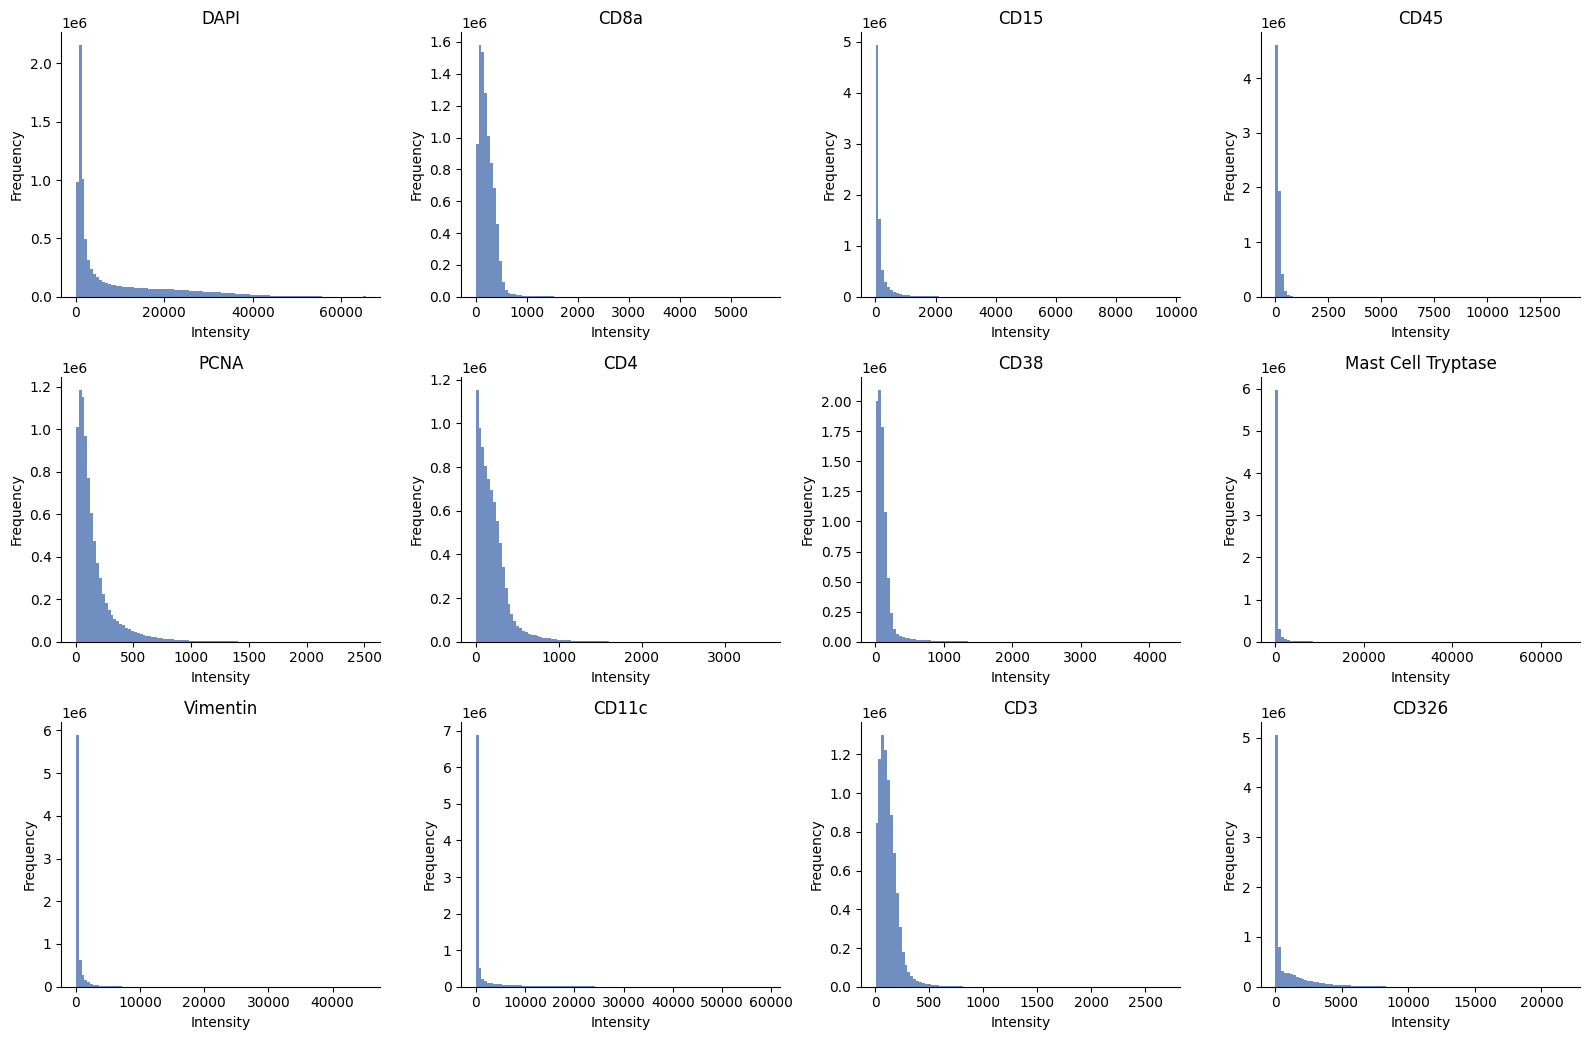

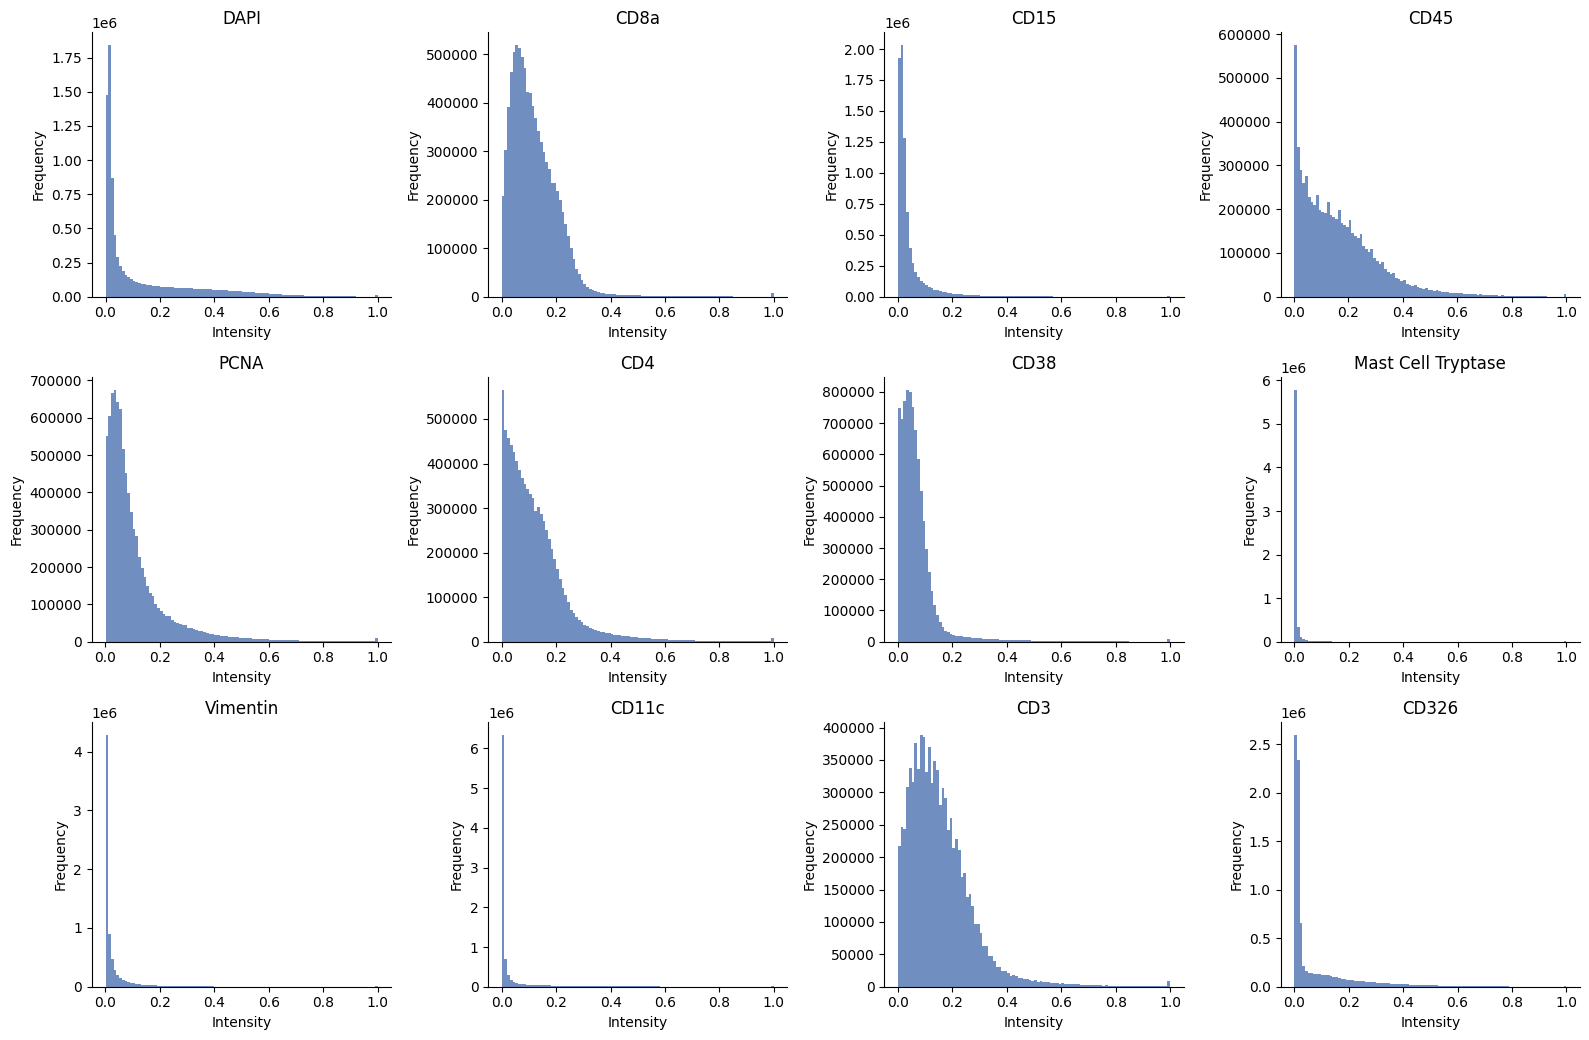

In [25]:
_channels_to_visualize = [
    "DAPI",
    "CD8a",
    "CD15",
    "CD45",
    "PCNA",
    "CD4",
    "CD38",
    "Mast Cell Tryptase",
    "Vimentin",
    "CD11c",
    "CD3",
    "CD326",
]

ax = hp.qc.image_histogram(
    sdata,
    image_name="REAscreen_IO_CRC",
    channel=_channels_to_visualize,
    ncols=4,
    bins=100,
)

ax = hp.qc.image_histogram(
    sdata,
    image_name="REAscreen_IO_CRC_normalized",
    channel=_channels_to_visualize,
    ncols=4,
    bins=100,
)

In [26]:
# Calculate intensities for cell segmentations.
marker_channels = [channel for channel in successful_channels]

sdata = hp.tb.allocate_intensity(
    sdata,
    image_name="REAscreen_IO_CRC_normalized",
    labels_name="labels_cells_instanseg",
    output_table_name="table_cells",
    channels=marker_channels,
    mode="mean",  # When set to "sum", the total intensity for each channel will be added to `.X` of the table layer; if set to `"mean"`, it calculates the average intensity per channel.
    # obs_stats=["sum", "mean", "count", "var", "kurtosis", "skew", "max", "min"] # Stats that will be added to `.obs` of `output_layer`
    chunks=2048,
    to_coordinate_system="global_1",
    overwrite=True,
)

2026-05-28 12:50:20.802 | WARNING  | harpy.utils._aggregate:_center_of_mass:884 - Count was computed for a different index. Recalculating.


In [27]:
# z-scoring before leiden clustering

sdata = hp.tb.preprocess_proteomics(
    sdata,
    labels_name="labels_cells_instanseg",
    table_name="table_cells",
    output_table_name="table_cells_z_scored",
    calculate_cell_size=False,
    size_norm=False,
    library_norm=False,
    log1p=False,
    scale=True,
    max_value_scale=5,
    q=None,
    calculate_pca=False,
    raw_counts_key="mean_counts",
    overwrite=True,
)


2026-05-28 12:50:21.416 | INFO     | harpy.table._preprocess:preprocess:338 - Saving non preprocessed data matrix to the AnnData '.layers[mean_counts]'.


In [28]:
microns_per_pixel = 0.17

sdata = hp.tb.add_regionprops(
    sdata,
    labels_name="labels_cells_instanseg",
    table_name="table_cells_z_scored",
    output_table_name="table_cells_z_scored",
    properties=["perimeter", "eccentricity", "convex_area", "area"],
    overwrite=True,
)

# convert to microns:
sdata["table_cells_z_scored"].obs["perimeter"] = sdata["table_cells_z_scored"].obs["perimeter"] * microns_per_pixel
sdata["table_cells_z_scored"].obs["convex_area"] = (
    sdata["table_cells_z_scored"].obs["convex_area"] * microns_per_pixel**2
)

sdata["table_cells_z_scored"].obs["area"] = sdata["table_cells_z_scored"].obs["area"] * microns_per_pixel**2
sdata["table_cells_z_scored"].obs[["perimeter", "eccentricity", "convex_area", "area"]].head()

2026-05-28 12:50:26.337 | WARNING  | harpy.utils._io:_incremental_io_on_disk:86 - Element with name 'table_cells_z_scored' already exists. Overwriting...


,perimeter,eccentricity,convex_area,area
cells,,,,
105_labels_cells_instanseg_d877b770,22.182498,0.639923,30.8652,29.1312
129_labels_cells_instanseg_d877b770,2.040000,1.000000,0.4046,0.4046
133_labels_cells_instanseg_d877b770,30.026661,0.848078,43.2633,40.1421
141_labels_cells_instanseg_d877b770,22.634163,0.828831,25.4609,23.4957
145_labels_cells_instanseg_d877b770,23.484163,0.618995,27.9752,25.5765


,labels_name,total_instances,total_area_μm²,covered_area_μm²,covered_area_percentage
0,labels_cells_instanseg,3233,260100.0,126715.7492,48.718089


2026-05-28 12:50:27.029 | INFO     | harpy.qc._qc_segmentation:segmentation_histogram:162 - Calculating cell size for labels element 'labels_cells_instanseg'.
2026-05-28 12:50:27.147 | INFO     | harpy.qc._qc_segmentation:segmentation_histogram:166 - Converting cell area from pixels to square microns using microns_per_pixel=0.17.


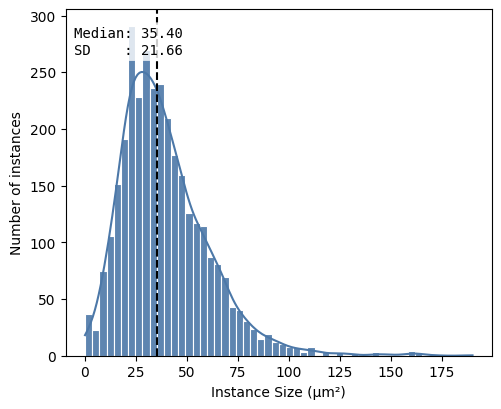

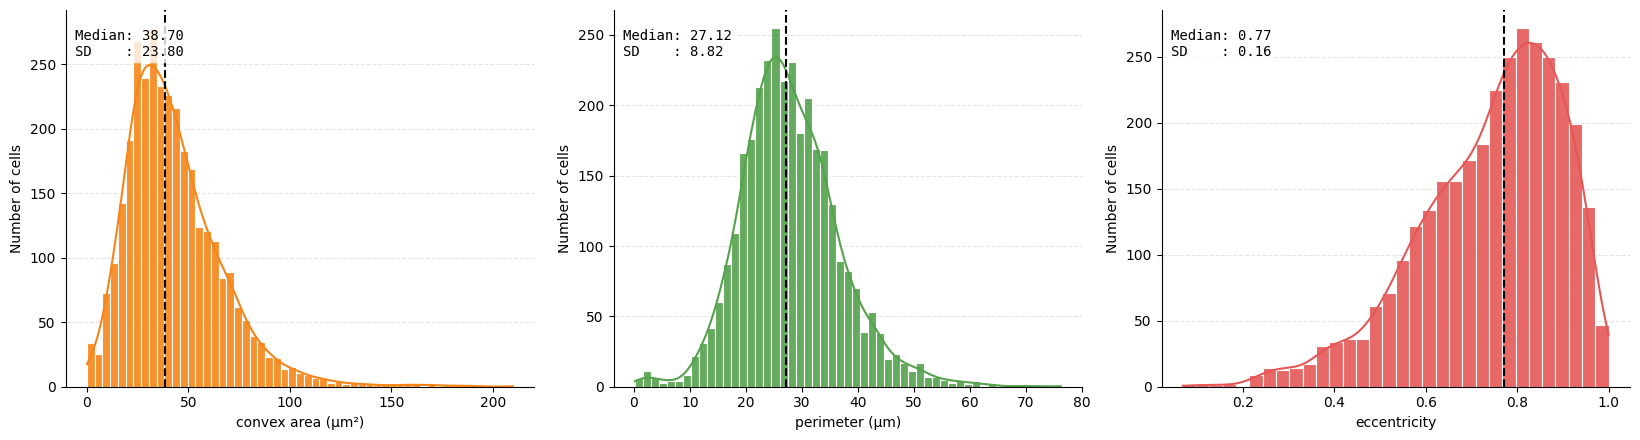

In [29]:
df = hp.qc.segmentation_coverage(
    sdata,
    labels_name="labels_cells_instanseg",
    microns_per_pixel=microns_per_pixel,
)
display(df)
hp.qc.segmentation_histogram(
    sdata,
    labels_name="labels_cells_instanseg",
    microns_per_pixel=microns_per_pixel,
)

metrics = (
    ("obs", "convex_area"),
    ("obs", "perimeter"),
    ("obs", "eccentricity"),
)

ax = hp.qc.metrics_histogram(
    sdata,
    labels_name="labels_cells_instanseg",
    table_name="table_cells_z_scored",
    display_column=["convex area (μm²)", "perimeter (μm)", "eccentricity"],
    color=[
        "#F58518",
        "#54A24B",
        "#E45756",
    ],
    metrics=metrics,
)

### 4.2 Filter segmentation masks based on size and artifacts

In [30]:
min_area_um2 = 10  # Minimum size of segmentation objects (in square micrometer).
max_area_um2 = 200  # Maximum size of segmentation objects (in square micrometer).

sdata["table_cells_z_scored"].obs["filter_on_size"] = (
    ~sdata["table_cells_z_scored"].obs["area"].between(10, 200)
).astype("category")


# @ Julien -> could you add similar logic for the artefacts. I.e. we annotate the Anndata table with a boolean column
# for the final filter we than simply combine all these boolean column, and filter the table.
# I prefer filtering the table than filtering a segmentation mask. As the AnnData table is an annotion of mask, so all info can live there.

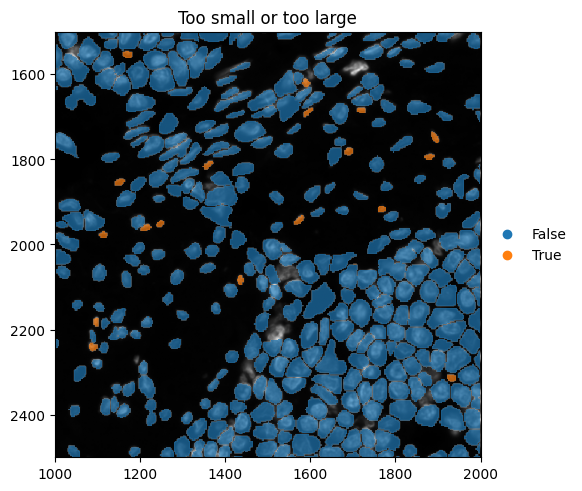

In [31]:
image_name = "REAscreen_IO_CRC"
to_coordinate_system = "global_1"

ax = hp.pl.plot_sdata(
    sdata,
    image_name=image_name,
    channel="DAPI",  # or another channel you want as background
    labels_name="labels_cells_instanseg",
    table_name="table_cells_z_scored",
    color="filter_on_size",
    crd=[1000, 2000, 1500, 2500],
    to_coordinate_system=to_coordinate_system,
    render_images_kwargs={
        "cmap": "gray",
        "scale": "scale1",
    },
    render_labels_kwargs={
        "fill_alpha": 0.7,
        "outline_alpha": 0.2,
    },
    show_kwargs={
        "title": "Too small or too large",
        "colorbar": False,
    },
)

In [32]:
# Now add the column "contains nucleus".
sdata["table_cells_z_scored"].obs.head()

,cell_ID,fov_labels,perimeter,eccentricity,convex_area,area,filter_on_size
cells,,,,,,,
105_labels_cells_instanseg_d877b770,105,labels_cells_instanseg,22.182498,0.639923,30.8652,29.1312,False
129_labels_cells_instanseg_d877b770,129,labels_cells_instanseg,2.040000,1.000000,0.4046,0.4046,True
133_labels_cells_instanseg_d877b770,133,labels_cells_instanseg,30.026661,0.848078,43.2633,40.1421,False
141_labels_cells_instanseg_d877b770,141,labels_cells_instanseg,22.634163,0.828831,25.4609,23.4957,False
145_labels_cells_instanseg_d877b770,145,labels_cells_instanseg,23.484163,0.618995,27.9752,25.5765,False


In [ ]:
cell_labels_ids = da.unique(sdata["labels_cells_instanseg"].data).compute()
nuclei_labels_ids = da.unique(sdata["labels_nuclei_cellpose_aligned"].data).compute()

cell_without_nucleus_ids = np.setdiff1d(
    cell_labels_ids,
    nuclei_labels_ids,
)

cell_without_nucleus_ids

sdata["table_cells_z_scored"].obs["has_nucleus"] = ~sdata["table_cells_z_scored"].obs["cell_ID"].isin(
    cell_without_nucleus_ids
)
sdata["table_cells_z_scored"].obs["has_nucleus"] = sdata["table_cells_z_scored"].obs["has_nucleus"].astype("category")

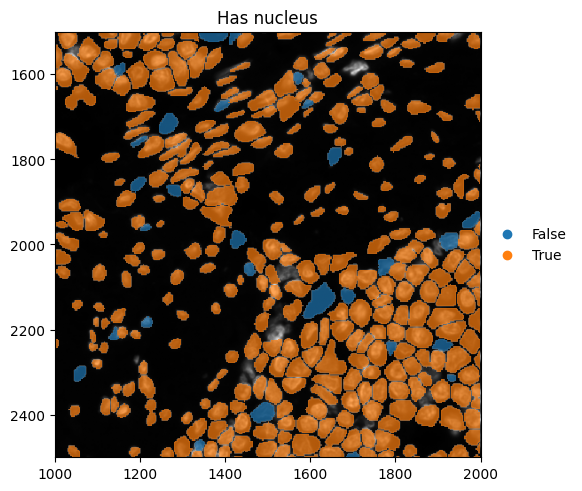

In [34]:
image_name = "REAscreen_IO_CRC"
to_coordinate_system = "global_1"

ax = hp.pl.plot_sdata(
    sdata,
    image_name=image_name,
    channel="DAPI",  # or another channel you want as background
    labels_name="labels_cells_instanseg",
    table_name="table_cells_z_scored",
    color="has_nucleus",
    crd=[1000, 2000, 1500, 2500],
    to_coordinate_system=to_coordinate_system,
    render_images_kwargs={
        "cmap": "gray",
        "scale": "scale1",
    },
    render_labels_kwargs={
        "fill_alpha": 0.7,
        "outline_alpha": 0.2,
    },
    show_kwargs={
        "title": "Has nucleus",
        "colorbar": False,
    },
)

In [35]:
from napari_harpy import Interactive

Interactive(sdata, widgets="viewer")

Lets filter on size (you could also filter on other properties), and write the result to a new slot.

In [36]:
from spatialdata.models import TableModel

adata = sdata["table_cells_z_scored"]

spatialdata_attrs = adata.uns[TableModel.ATTRS_KEY]
region_key = spatialdata_attrs[TableModel.REGION_KEY_KEY]
instance_key = spatialdata_attrs[TableModel.INSTANCE_KEY]

mask = adata.obs["filter_on_size"].eq(False)

adata_filtered = adata[mask].copy()

sdata = hp.tb.add_table(
    sdata,
    adata=adata_filtered,
    output_table_name="table_cells_z_scored_filterd",
    region=list(adata_filtered.obs[region_key].unique()),
    instance_key=instance_key,
    region_key=region_key,
    overwrite=True,
)

In [37]:
from napari_harpy import Interactive

Interactive(sdata, widgets="viewer")

2026-05-28 12:50:42.519 | WARNING  | harpy.utils._io:_incremental_io_on_disk:86 - Element with name 'table_cells_z_scored_filterd' already exists. Overwriting...


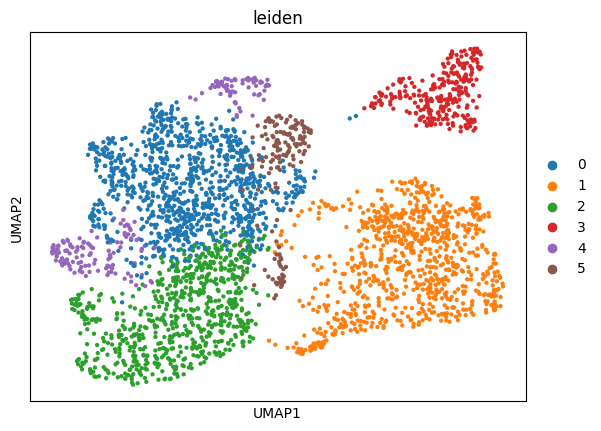

In [ ]:
# Leiden clustering
sdata = hp.tb.leiden(
    sdata,
    labels_name="labels_cells_instanseg",
    table_name="table_cells_z_scored_filterd",
    output_table_name="table_cells_z_scored_filterd",
    calculate_umap=True,
    calculate_neighbors=True,
    n_pcs=17,  # The number of principal components to use when calculating neighbors.
    n_neighbors=35,  # The number of neighbors to consider when calculating neighbors.
    resolution=0.4,
    rank_genes=True,
    key_added="leiden",
    overwrite=True,
)

# Plot UMAP
sc.pl.umap(
    sdata.tables["table_cells_z_scored_filterd"],
    color=["leiden"],
    show=True,
)

<Axes: title={'center': 'Leiden clusters'}>

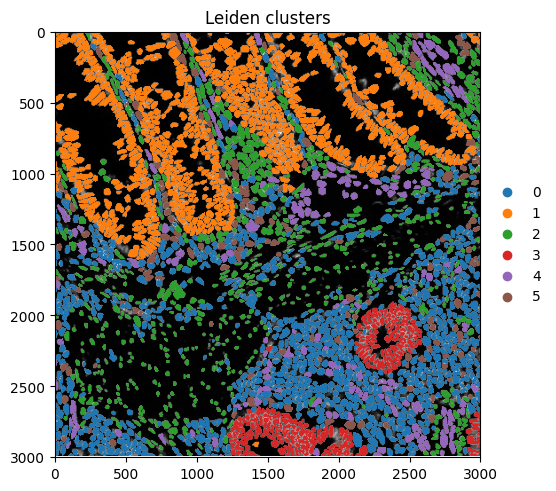

In [39]:
# Plot clusters spatially
hp.pl.plot_sdata(
    sdata,
    image_name="REAscreen_IO_CRC",
    channel="DAPI",
    table_name="table_cells_z_scored_filterd",
    labels_name="labels_cells_instanseg",
    color="leiden",
    to_coordinate_system="global_1",
    render_images_kwargs={"cmap": "grey"},
    render_labels_kwargs={"fill_alpha": 1},
    show_kwargs={"title": "Leiden clusters", "colorbar": False},
)

In [40]:
Interactive(sdata, widgets="viewer")

<Axes: >

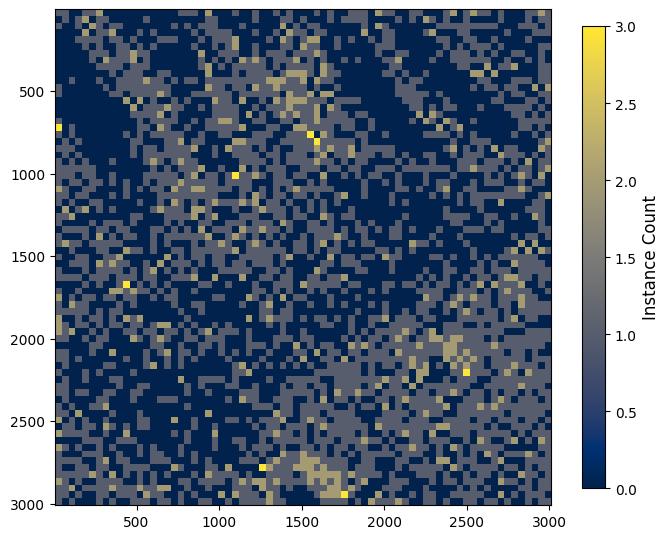

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(8, 8))

hp.pl.plot_instance_density(
    sdata,
    bin_size=7
    / 0.17,  # bin size in pixels if .obsm["spatial"] of the AnnData table "table_transcriptomics" is in pixels
    spatial_key="spatial",
    table_name="table_cells_z_scored_filterd",
    cmap="cividis",
    ax=ax,
)

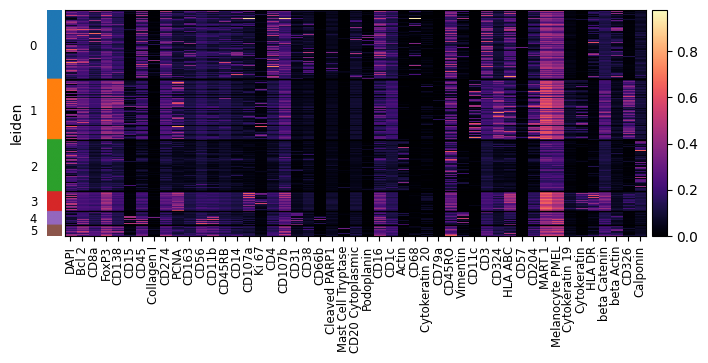

In [42]:
sc.pl.heatmap(
    sdata["table_cells_z_scored_filterd"],
    var_names=sdata["table_cells_z_scored_filterd"].var_names,
    groupby="leiden",
    swap_axes=False,
    norm=None,
    cmap="magma",
    figsize=(8, 3),
    show_gene_labels=True,
)

2026-05-28 12:50:45.430 | INFO     | harpy.table._cluster_intensity:cluster_intensity:80 - Weighted (by instance size) average intensity per cluster (cluster key: 'leiden') will be stored in 'sdata[table_cells_z_scored_filterd].uns[leiden_weighted_intensity]'.
2026-05-28 12:50:45.435 | WARNING  | harpy.table._cluster_intensity:cluster_intensity:103 - Column with name 'shapeSize' not found in 'sdata[table_cells_z_scored_filterd].obs', calculating instance size for all instances in ['labels_cells_instanseg'].
2026-05-28 12:50:45.435 | INFO     | harpy.table._cluster_intensity:cluster_intensity:108 - Calculating instance size from provided labels element 'labels_cells_instanseg'
2026-05-28 12:50:48.447 | WARNING  | harpy.utils._io:_incremental_io_on_disk:86 - Element with name 'table_cells_z_scored_filterd' already exists. Overwriting...


,leiden,DAPI,Bcl 2,CD8a,FoxP3,CD138,CD15,CD45,Collagen I,CD274,...,CD204,MART 1,Melanocyte PMEL,Cytokeratin 19,Cytokeratin,HLA DR,beta Catenin,beta Actin,CD326,Calponin
0,0,0.245211,0.232866,0.156310,0.263334,0.174529,0.020484,0.215360,0.028960,0.205325,...,0.129110,0.364836,0.326785,0.029632,0.003393,0.088866,0.130411,0.113970,0.019979,0.084807
1,1,0.231369,0.246221,0.176101,0.319538,0.286317,0.095771,0.167179,0.007214,0.203487,...,0.234178,0.479294,0.400463,0.089349,0.090436,0.020977,0.229363,0.061159,0.268128,0.092074
2,2,0.206218,0.180625,0.092589,0.151786,0.132013,0.016224,0.062237,0.016995,0.099124,...,0.040688,0.219282,0.215414,0.021986,0.002838,0.027880,0.115220,0.041995,0.023740,0.135343
3,3,0.309576,0.223328,0.214585,0.389630,0.207715,0.022198,0.206370,0.011173,0.262434,...,0.162353,0.578587,0.473612,0.093496,0.188895,0.265621,0.312598,0.071663,0.123678,0.124685
4,4,0.153542,0.243083,0.133399,0.277316,0.145843,0.121074,0.239040,0.019284,0.193807,...,0.133485,0.352354,0.368452,0.029845,0.004097,0.038301,0.153085,0.086009,0.016367,0.059892
5,5,0.251151,0.301708,0.172102,0.311442,0.216902,0.032230,0.212176,0.022502,0.193076,...,0.145823,0.371035,0.386339,0.037717,0.008471,0.048739,0.182401,0.166655,0.034831,0.064285


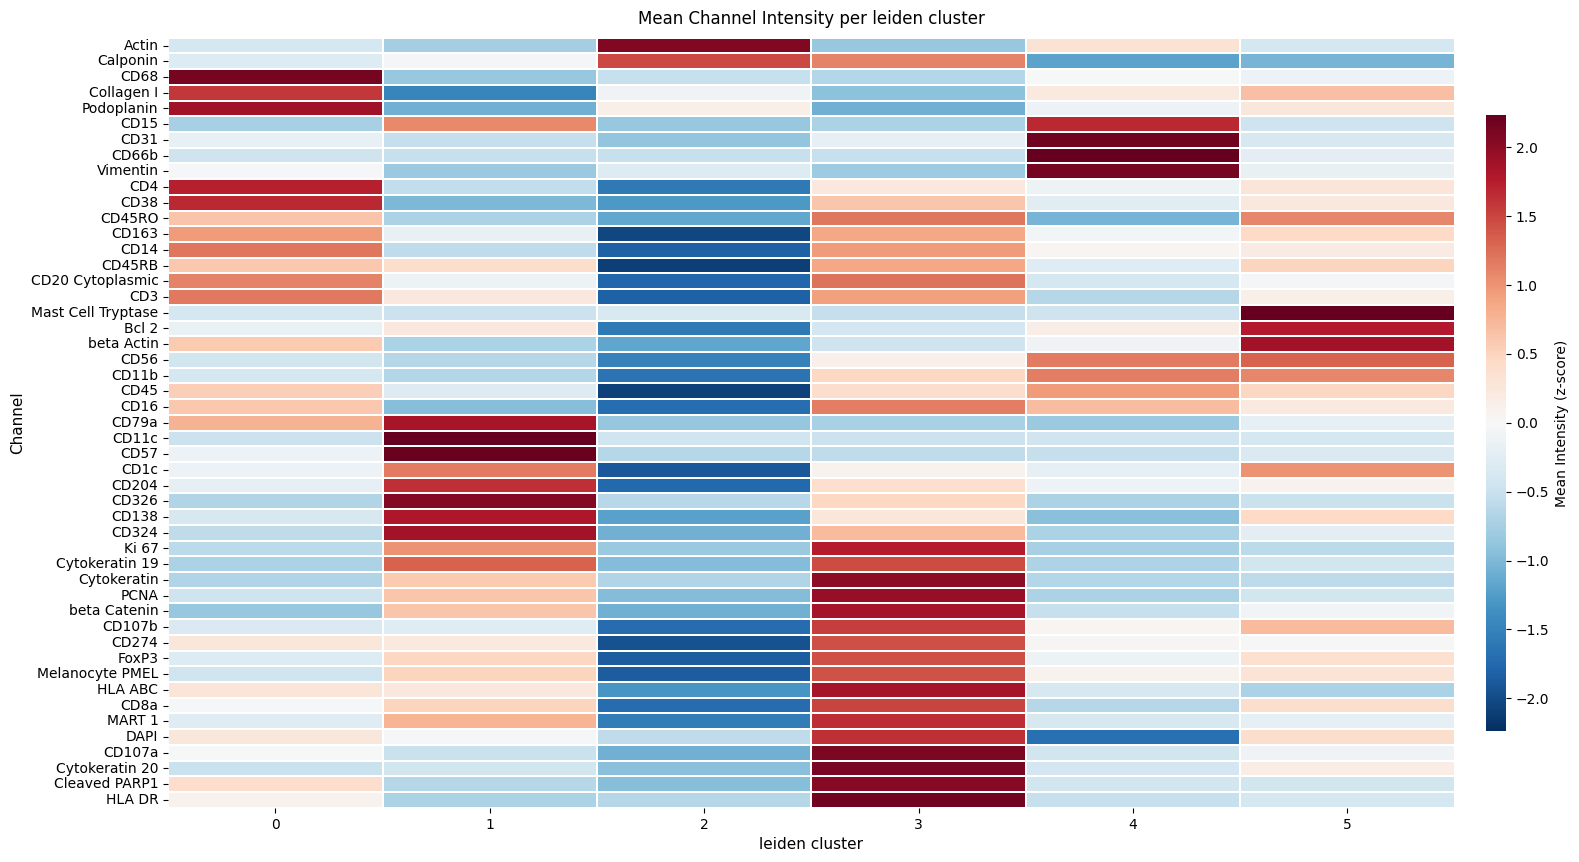

In [43]:
# calculate the mean itensity per leiden cluster
cluster_key = "leiden"

sdata = hp.tb.cluster_intensity(
    sdata,
    table_name="table_cells_z_scored_filterd",
    labels_name="labels_cells_instanseg",
    output_table_name="table_cells_z_scored_filterd",
    cluster_key="leiden",
    layer_mean_intensities="mean_counts",
    cluster_key_uns=f"{cluster_key}_weighted_intensity",
    overwrite=True,
)

display(sdata["table_cells_z_scored_filterd"].uns[f"{cluster_key}_weighted_intensity"])

ax = hp.pl.cluster_intensity_heatmap(
    sdata,
    table_name="table_cells_z_scored_filterd",
    cluster_key="leiden",
    z_score=True,
    figsize=(20, 10),
)